# 07 — XGBoost Baseline Model

## Objective

This notebook trains and evaluates an XGBoost classifier for vehicular misbehavior detection using the preprocessed VeReMi dataset.

The objective is to establish an XGBoost baseline and compare its performance with the Logistic Regression, Decision Tree, and Random Forest models developed in the previous notebooks.

The evaluation focuses on:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- Classification Report
- ROC Curve
- Precision-Recall Curve
- Feature Importance
- Cross-Validation

The same training and testing datasets used for the previous baseline models are used here to maintain a fair comparison.

## 2. Import Required Libraries

The following libraries are used for data loading, model training, evaluation, visualization, and saving the trained model and experiment outputs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
import joblib

from pathlib import Path

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.model_selection import StratifiedKFold, cross_val_score

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Project Paths

The project uses the previously generated processed training and testing datasets.

The paths are defined relative to the notebook location so that the notebook remains reproducible within the project repository.

The trained XGBoost model and evaluation outputs will also be saved in their respective project directories.

In [2]:
# Project paths

PROJECT_ROOT = Path("..")

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"
MODEL_PATH = PROJECT_ROOT / "models" / "baseline_models"
OUTPUT_METRICS = PROJECT_ROOT / "outputs" / "metrics"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"

# Create output directories if they do not already exist
MODEL_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_METRICS.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

print("Processed data path:", PROCESSED_PATH)
print("Model path:", MODEL_PATH)
print("Metrics path:", OUTPUT_METRICS)
print("Figures path:", OUTPUT_FIGURES)

Processed data path: ..\data\processed
Model path: ..\models\baseline_models
Metrics path: ..\outputs\metrics
Figures path: ..\outputs\figures


## 4. Load Processed Training and Testing Data

The preprocessed training and testing datasets generated in Notebook 03 are loaded for XGBoost training.

Using the same datasets as the previous baseline models ensures that the XGBoost results can be compared fairly with Logistic Regression, Decision Tree, and Random Forest.

In [3]:
# Load processed datasets

train_df = pd.read_csv(PROCESSED_PATH / "train_processed.csv")
test_df = pd.read_csv(PROCESSED_PATH / "test_processed.csv")

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (80000, 23)
Testing data shape: (20000, 23)


## 5. Separate Features and Target

The `attack` column is the target variable.

- `attack = 0` represents normal/non-malicious data.
- `attack = 1` represents malicious/misbehavior data.

All remaining columns are used as input features for the XGBoost classifier.

In [4]:
# Separate features and target

X_train = train_df.drop(columns=["attack"])
y_train = train_df["attack"]

X_test = test_df.drop(columns=["attack"])
y_test = test_df["attack"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nFeature columns:")
print(X_train.columns.tolist())

X_train shape: (80000, 22)
X_test shape: (20000, 22)
y_train shape: (80000,)
y_test shape: (20000,)

Feature columns:
['type', 'rcvTime', 'pos_0', 'pos_1', 'pos_noise_0', 'pos_noise_1', 'spd_0', 'spd_1', 'spd_noise_0', 'spd_noise_1', 'acl_0', 'acl_1', 'acl_noise_0', 'acl_noise_1', 'hed_0', 'hed_1', 'hed_noise_0', 'hed_noise_1', 'pos_magnitude', 'speed_magnitude', 'acceleration_magnitude', 'heading_magnitude']


## 6. Verify Target Distribution

The class distribution of the training and testing sets is checked before model training.

This confirms that the same class balance used in the previous baseline experiments has been retained.

In [5]:
# Check class distribution

print("Training Target Distribution")
print(y_train.value_counts())
print("\nTraining Target Proportion")
print(y_train.value_counts(normalize=True))

print("\n" + "=" * 50 + "\n")

print("Testing Target Distribution")
print(y_test.value_counts())
print("\nTesting Target Proportion")
print(y_test.value_counts(normalize=True))

Training Target Distribution
attack
0    43623
1    36377
Name: count, dtype: int64

Training Target Proportion
attack
0    0.545288
1    0.454713
Name: proportion, dtype: float64


Testing Target Distribution
attack
0    10906
1     9094
Name: count, dtype: int64

Testing Target Proportion
attack
0    0.5453
1    0.4547
Name: proportion, dtype: float64


## 7. Configure XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is used as the next baseline model.

Unlike the previously evaluated Logistic Regression, Decision Tree, and Random Forest models, XGBoost builds an ensemble of decision trees sequentially, where each new tree attempts to correct errors made by the previous trees.

For this baseline experiment, a controlled set of parameters is used rather than extensive hyperparameter tuning. Hyperparameter optimization will be performed later if XGBoost provides promising performance.

The model is configured for binary classification because the target variable contains two classes:

- `0` — Normal
- `1` — Attack

In [6]:
# Configure XGBoost baseline model

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print(xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)


## 8. Train XGBoost Baseline Model

The XGBoost classifier is trained using the same 80,000 training samples and 22 input features used by the previous baseline models.

Training time is recorded to provide a basic measure of computational cost.

No hyperparameter tuning is performed at this stage. The purpose of this experiment is to establish a baseline XGBoost result for comparison with Logistic Regression, Decision Tree, and Random Forest.

In [7]:
# Train XGBoost baseline model

start_time = time.time()

xgb.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"XGBoost Training Time: {training_time:.3f} seconds")
print("\nXGBoost model trained successfully.")

XGBoost Training Time: 3.196 seconds

XGBoost model trained successfully.


## 9. Inspect Trained XGBoost Model

The fitted XGBoost model is inspected to confirm that training produced the expected number of trees and retained the 22 input features used by the previous baseline models.

This provides a quick verification before saving the trained model.

In [8]:
# Inspect trained XGBoost model

print("Number of estimators:", xgb.n_estimators)
print("Number of input features:", xgb.n_features_in_)

print("\nFeature names:")
print(X_train.columns.tolist())

print("\nClasses:")
print(xgb.classes_)

Number of estimators: 200
Number of input features: 22

Feature names:
['type', 'rcvTime', 'pos_0', 'pos_1', 'pos_noise_0', 'pos_noise_1', 'spd_0', 'spd_1', 'spd_noise_0', 'spd_noise_1', 'acl_0', 'acl_1', 'acl_noise_0', 'acl_noise_1', 'hed_0', 'hed_1', 'hed_noise_0', 'hed_noise_1', 'pos_magnitude', 'speed_magnitude', 'acceleration_magnitude', 'heading_magnitude']

Classes:
[0 1]


## 10. Save the Trained XGBoost Model

The trained XGBoost model is saved so that it can be reused later without retraining.

The model file is stored in the `models/baseline_models/` directory along with the other baseline models.

The trained model itself is not required to be uploaded to GitHub if its size exceeds GitHub's file-size limit. The reproducible training notebook and evaluation outputs remain part of the research repository.

In [9]:
# Save trained XGBoost model

xgb_model_path = MODEL_PATH / "xgboost_model.json"

xgb.save_model(xgb_model_path)

print("XGBoost model saved successfully.")
print("Saved at:", xgb_model_path)

XGBoost model saved successfully.
Saved at: ..\models\baseline_models\xgboost_model.json


## 11. Verify Saved XGBoost Model

The saved XGBoost model file is checked to confirm that it exists at the expected location and that its file size is non-zero.

This ensures that the trained model was successfully written to disk before it is used for prediction.

In [10]:
# Verify saved model file

if xgb_model_path.exists():
    file_size_mb = xgb_model_path.stat().st_size / (1024 * 1024)

    print("Model file exists: Yes")
    print(f"Model file size: {file_size_mb:.2f} MB")
    print("Model path:", xgb_model_path)
else:
    print("Model file exists: No")

Model file exists: Yes
Model file size: 1.32 MB
Model path: ..\models\baseline_models\xgboost_model.json


## 12. XGBoost Prediction

The trained XGBoost model is used to generate predictions on the unseen test dataset.

Two outputs are generated:

- Class predictions (`0` or `1`)
- Attack probabilities for the positive class (`1`)

Prediction time is also recorded to provide a basic measure of inference efficiency.

In [11]:
# Generate XGBoost predictions

start_time = time.time()

y_pred = xgb.predict(X_test)
y_pred_proba = xgb.predict_proba(X_test)[:, 1]

prediction_time = time.time() - start_time

print(f"Prediction Time: {prediction_time:.3f} seconds")

print("\nFirst 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Attack Probabilities:")
print(y_pred_proba[:10])

Prediction Time: 0.116 seconds

First 10 Predictions:
[0 0 1 0 1 0 0 1 1 0]

First 10 Attack Probabilities:
[0.36970338 0.34171587 0.5605175  0.48903427 0.5262211  0.41488785
 0.4961548  0.66901237 0.7270321  0.47454682]


## 13. XGBoost Performance Evaluation

The XGBoost classifier is evaluated on the unseen test dataset using the same metrics used for the previous baseline models.

The following metrics are calculated:

- **Accuracy** — Overall proportion of correctly classified samples.
- **Precision** — Proportion of predicted attacks that are actually attacks.
- **Recall** — Proportion of actual attacks correctly detected.
- **F1 Score** — Harmonic mean of precision and recall.
- **ROC-AUC** — Measures the model's ability to distinguish between normal and attack samples across different classification thresholds.

These metrics will later be compared with Logistic Regression, Decision Tree, and Random Forest.

In [12]:
# Calculate XGBoost evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

xgb_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

print(xgb_metrics)

      Metric     Value
0   Accuracy  0.550900
1  Precision  0.510260
2     Recall  0.306246
3   F1 Score  0.382765
4    ROC AUC  0.556428


## 14. XGBoost Confusion Matrix

The confusion matrix provides a detailed view of the classification results by showing the number of:

- True Negatives (TN): Normal samples correctly classified as normal.
- False Positives (FP): Normal samples incorrectly classified as attacks.
- False Negatives (FN): Attack samples incorrectly classified as normal.
- True Positives (TP): Attack samples correctly classified as attacks.

For this research, false negatives are particularly important because they represent malicious vehicular messages that the model failed to detect.

Confusion Matrix:
[[8233 2673]
 [6309 2785]]


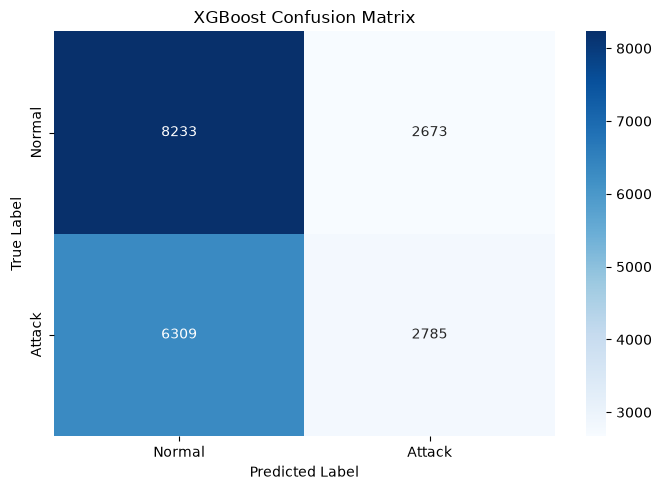

Figure saved at: ..\outputs\figures\xgb_confusion_matrix.png


In [13]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost Confusion Matrix")

plt.tight_layout()

confusion_matrix_path = OUTPUT_FIGURES / "xgb_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved at:", confusion_matrix_path)

## 15. XGBoost Classification Report

The classification report provides precision, recall, F1 score, and support for each class separately.

This is particularly important because the project focuses on detecting vehicular misbehavior. Therefore, the performance for the attack class (`1`) must be examined separately rather than relying only on overall accuracy.

The report will help identify whether the model is better at recognizing normal messages or malicious messages.

In [14]:
# Generate classification report

report = classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Attack"]
)

print(report)

# Save classification report

report_dict = classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Attack"],
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

report_path = OUTPUT_METRICS / "xgboost_classification_report.csv"

report_df.to_csv(report_path)

print("\nClassification report saved at:", report_path)

              precision    recall  f1-score   support

      Normal       0.57      0.75      0.65     10906
      Attack       0.51      0.31      0.38      9094

    accuracy                           0.55     20000
   macro avg       0.54      0.53      0.51     20000
weighted avg       0.54      0.55      0.53     20000


Classification report saved at: ..\outputs\metrics\xgboost_classification_report.csv


## 16. ROC Curve

The Receiver Operating Characteristic (ROC) curve evaluates the model's ability to distinguish between normal and attack samples across different classification thresholds.

The curve plots:

- True Positive Rate (Recall)
- False Positive Rate

The Area Under the ROC Curve (ROC-AUC) summarizes the overall discrimination ability of the model.

A value close to 0.5 indicates performance close to random classification, while higher values indicate better class separation.

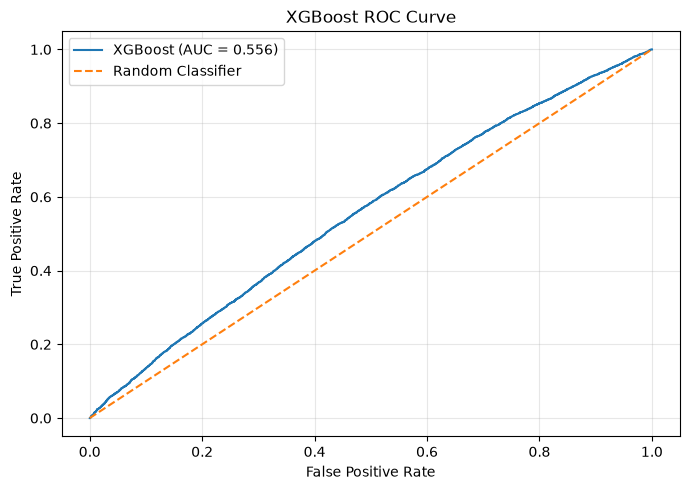

ROC curve saved at: ..\outputs\figures\xgb_roc_curve.png


In [15]:
# Generate ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

roc_path = OUTPUT_FIGURES / "xgb_roc_curve.png"

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved at:", roc_path)

## ROC Curve

The Receiver Operating Characteristic (ROC) curve is used to evaluate the ability of the XGBoost model to distinguish between normal and attack samples across different classification thresholds.

The Area Under the Curve (AUC) obtained by the XGBoost model is **0.556**.

An AUC of 0.5 represents random classification, while a value closer to 1.0 indicates better discrimination. The obtained AUC of 0.556 shows that the current XGBoost model provides only a **slight improvement over random classification** on the 100,000-row working dataset.

The ROC curve is compared with the random-classifier baseline (AUC = 0.5). Although the XGBoost curve remains slightly above the baseline for most thresholds, the separation is limited.

This result suggests that further improvement through feature engineering, hyperparameter tuning, class-specific analysis, or evaluation on the full dataset may be necessary before using the model for reliable misbehavior detection.

## 17. Precision-Recall Curve

The Precision-Recall (PR) curve evaluates the performance of the XGBoost model at different classification thresholds.

The curve shows the relationship between:

- Precision — the proportion of predicted attacks that are actually attacks.
- Recall — the proportion of actual attacks correctly detected.

The Precision-Recall curve is particularly useful for this project because the main objective is to detect vehicular misbehavior. Therefore, the ability to identify the attack class is more important than accuracy alone.

The curve also helps examine how precision changes as the model attempts to detect a larger proportion of attack samples.

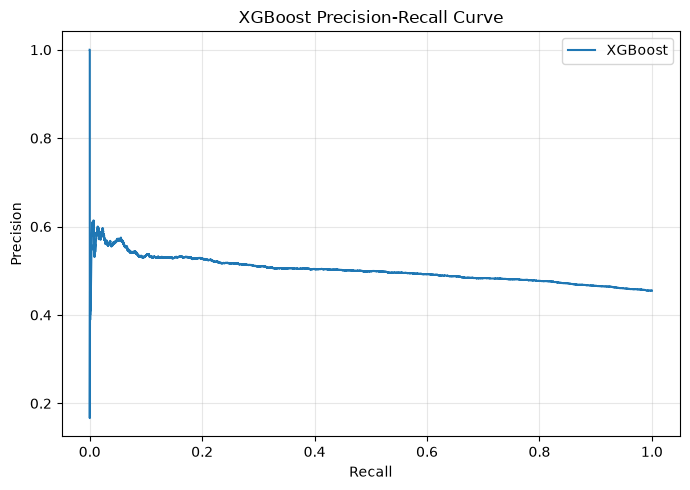

Precision-Recall curve saved at: ..\outputs\figures\xgb_precision_recall_curve.png


In [16]:
# Generate Precision-Recall curve

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    y_pred_proba
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve,
    precision_curve,
    label="XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

pr_curve_path = OUTPUT_FIGURES / "xgb_precision_recall_curve.png"

plt.savefig(
    pr_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Precision-Recall curve saved at:", pr_curve_path)

## 17. Precision-Recall Curve

The Precision-Recall (PR) curve evaluates the trade-off between **precision** and **recall** at different classification thresholds.

- **Precision** represents the proportion of samples predicted as attacks that are actually attacks.
- **Recall** represents the proportion of actual attack samples that are correctly detected.

The PR curve is particularly useful for misbehavior detection because correctly identifying attack samples is an important objective of the system.

The XGBoost model maintains a precision of approximately **0.50–0.60** over a substantial portion of the recall range. However, precision gradually decreases as recall increases, reaching approximately **0.45** at very high recall.

Since the attack class represents approximately **45.5%** of the testing dataset, the curve should be interpreted relative to this class prevalence. The model therefore shows some ability to distinguish attack samples, but the improvement over the class-prevalence baseline is limited.

Overall, the Precision-Recall curve indicates that the current XGBoost model provides **limited but measurable attack-detection capability** on the 100,000-row working dataset. Further improvement may require better feature engineering, hyperparameter tuning, class-specific analysis, or evaluation using the full VeReMi dataset.

## 18. Feature Importance

Feature importance is used to identify which input features contribute most to the predictions made by the XGBoost model.

XGBoost provides feature importance scores based on the contribution of each feature across the decision trees in the ensemble.

Higher importance indicates that a feature was used more frequently or contributed more strongly to the model's decision-making process.

Examining feature importance can help identify the vehicle-related parameters that are most useful for distinguishing between normal and attack samples.

In [18]:
# Get feature names directly from the training data
feature_names = X_train.columns.tolist()

# Get feature importance from the trained XGBoost model
importance = xgb.feature_importances_

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
feature_importance_df.head(15)

,Feature,Importance
1,rcvTime,0.067480
19,speed_magnitude,0.050198
2,pos_0,0.049806
18,pos_magnitude,0.049676
0,type,0.048537
20,acceleration_magnitude,0.045719
14,hed_0,0.045271
3,pos_1,0.044886
7,spd_1,0.044831
11,acl_1,0.044442


## 18. Feature Importance

Feature importance is used to identify which input features contribute most to the predictions made by the XGBoost model.

XGBoost provides an importance score for each feature based on its contribution to the decision trees in the ensemble. Higher importance values indicate that a feature was used more frequently or contributed more strongly to the model's predictions.

The feature importance analysis helps understand which characteristics of the Basic Safety Messages are most useful for distinguishing between normal and attack samples.

The top-ranked features include **rcvTime**, **speed_magnitude**, **pos_0**, **pos_magnitude**, and **type**. Among these, `rcvTime` has the highest importance score of approximately **0.0675**.

The results suggest that temporal information, position-related features, and motion-related features play an important role in the current XGBoost model.

However, feature importance should not be interpreted as direct causal influence. It only indicates the relative contribution of features within the trained model.

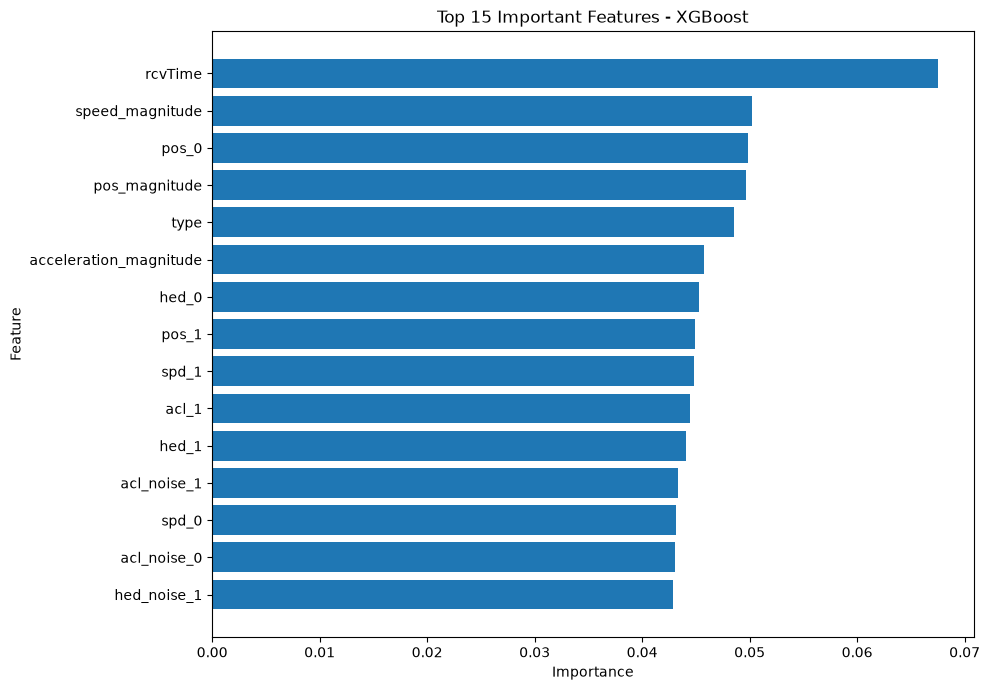

Feature importance figure saved at: ../outputs/figures/xgb_feature_importance.png


In [22]:
# XGBoost Feature Importance Plot

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features - XGBoost")

plt.tight_layout()

# Save figure using the known relative path
plt.savefig(
    "../outputs/figures/xgb_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Feature importance figure saved at:",
    "../outputs/figures/xgb_feature_importance.png"
)

## 18.1 Feature Importance Analysis

The XGBoost feature importance analysis shows that **rcvTime** is the most important feature, with an importance score of **0.0675**.

The next most important features are **speed_magnitude (0.0502)**, **pos_0 (0.0498)**, **pos_magnitude (0.0497)**, and **type (0.0485)**.

Other relatively important features include **acceleration_magnitude, hed_0, pos_1, spd_1, and acl_1**.

Overall, the important features include temporal information, position, speed, acceleration, and heading-related attributes. This indicates that both vehicle state and message-related characteristics contribute to the predictions made by the XGBoost model.

However, the importance values are relatively close to one another after the top-ranked feature. Therefore, the model does not rely exclusively on a small number of features. Also, feature importance represents the model's internal usage of features and should not be interpreted as evidence of causal relationships.

The relatively high importance of `rcvTime` is noteworthy and will be considered during later analysis to determine whether temporal information provides genuine predictive value or whether it may be associated with dataset-specific patterns.

## 19. Cross-Validation

Cross-validation is used to evaluate the stability and generalization of the XGBoost model across multiple subsets of the training data.

A 5-fold cross-validation procedure is used. The training data is divided into five folds, with the model trained on four folds and evaluated on the remaining fold in each iteration.

The process is repeated until every fold has been used as a validation set.

The mean cross-validation accuracy provides an overall estimate of model performance, while the standard deviation indicates how much the performance varies between folds.

A low standard deviation suggests that the model's performance is relatively stable across different subsets of the data.

In [23]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores:
[0.5578125 0.5525625 0.552625  0.5496875 0.554125 ]

Mean Accuracy: 0.5533625
Standard Deviation: 0.0026485255331976853


## 19.1 Cross-Validation Analysis

Five-fold cross-validation was performed to evaluate the stability of the XGBoost model.

The model achieved the following validation accuracies:

- Fold 1: **55.78%**
- Fold 2: **55.26%**
- Fold 3: **55.26%**
- Fold 4: **54.97%**
- Fold 5: **55.41%**

The mean cross-validation accuracy was **55.34%**, with a standard deviation of approximately **0.00265**.

The relatively small standard deviation indicates that the model's performance is consistent across the different validation folds. The mean cross-validation accuracy is also close to the independent test accuracy of **55.09%**, suggesting that the observed performance is reasonably stable.

However, the consistency of the model should not be interpreted as strong predictive performance. The results indicate that the current feature representation and baseline XGBoost configuration provide only limited classification capability for distinguishing normal and attack samples.

## 20. Baseline Model Comparison

The performance of the four baseline machine learning models is compared using accuracy, precision, recall, F1 score, and ROC-AUC.

Using multiple evaluation metrics is important because accuracy alone does not adequately represent the performance of a misbehavior detection system. In particular, recall and F1 score for the attack class are important because missed attacks represent malicious messages that remain undetected.

The comparison provides a common baseline for selecting a model for subsequent explainability analysis and further improvement.

In [24]:
# Baseline model comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.545200,
        0.544950,
        0.539450,
        0.550900
    ],
    "Precision": [
        0.497748,
        0.499399,
        0.491162,
        0.510260
    ],
    "Recall": [
        0.024302,
        0.319771,
        0.357488,
        0.306246
    ],
    "F1 Score": [
        0.046341,
        0.389891,
        0.413797,
        0.382765
    ],
    "ROC AUC": [
        0.534808,
        0.550115,
        0.536691,
        0.556428
    ]
})

display(model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.54520,0.497748,0.024302,0.046341,0.534808
1,Decision Tree,0.54495,0.499399,0.319771,0.389891,0.550115
2,Random Forest,0.53945,0.491162,0.357488,0.413797,0.536691
3,XGBoost,0.55090,0.510260,0.306246,0.382765,0.556428


## 20.1 Baseline Model Comparison Analysis

The comparison shows that none of the four baseline models provides consistently strong performance across all evaluation metrics.

XGBoost achieves the highest overall accuracy (**55.09%**), precision (**51.03%**), and ROC-AUC (**0.556**) among the evaluated models. However, its attack-class recall is **30.62%** and its F1 score is **38.28%**.

Random Forest achieves the highest attack-class recall (**35.75%**) and F1 score (**41.38%**), indicating that it detects a larger proportion of attack samples than the other baseline models. However, its overall accuracy and ROC-AUC are slightly lower than those of XGBoost.

Decision Tree provides moderate performance, while Logistic Regression performs poorly for attack detection, with an attack recall of only **2.43%** and an F1 score of **4.63%**.

Overall, the baseline experiments indicate that the current feature representation provides only limited predictive capability. Therefore, the results should be treated as a baseline rather than as the final performance of the proposed misbehavior detection framework.

For subsequent analysis, XGBoost is selected as an important candidate because it provides the highest ROC-AUC and overall accuracy, while Random Forest remains an important reference because of its higher attack recall and F1 score.

## 21. Baseline Findings and Model Selection

The baseline experiments were conducted using Logistic Regression, Decision Tree, Random Forest, and XGBoost on the 100,000-row working dataset.

The results show that the four models provide relatively similar overall performance, with accuracy values close to 55%. XGBoost achieved the highest accuracy (**55.09%**) and ROC-AUC (**0.556**), while Random Forest achieved the highest attack-class recall (**35.75%**) and F1 score (**41.38%**).

These results indicate that the current feature representation provides only limited predictive capability for distinguishing normal and attack samples. Therefore, the baseline models are treated as reference models rather than the final detection system.

XGBoost is selected as the primary model for the subsequent explainability analysis because it achieved the highest ROC-AUC and overall accuracy among the evaluated baseline models. Random Forest will be retained as an important comparison because of its higher attack-class recall and F1 score.

The next stage focuses on understanding the predictions of the selected XGBoost model using Explainable Artificial Intelligence (XAI), specifically SHAP (SHapley Additive exPlanations). This will allow the contribution of individual features to specific predictions to be examined rather than relying only on aggregate performance metrics.

In [25]:
print("XGBoost model:", type(xgb).__name__)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Number of features:", X_test.shape[1])

XGBoost model: XGBClassifier
X_test shape: (20000, 22)
y_test shape: (20000,)
Number of features: 22


## 22. SHAP Explainability

SHAP (SHapley Additive exPlanations) is used to explain the predictions produced by the XGBoost model.

SHAP assigns an importance value to each feature for an individual prediction. A positive SHAP value indicates that the feature pushes the prediction toward the attack class, while a negative value indicates that the feature pushes the prediction toward the normal class.

This provides a more detailed interpretation of the model than global feature importance alone. Global feature importance shows which features are generally important to the model, whereas SHAP can show how individual feature values influence specific predictions.

In this project, SHAP explanations will be used as the structured explanation layer before generating human-readable misbehavior reports using the LLM component.

In [26]:
# Check SHAP installation and version

import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


## 23. SHAP Explainer

A SHAP TreeExplainer is used to explain the predictions of the trained XGBoost model.

TreeExplainer is designed for tree-based machine learning models and provides an efficient method for calculating SHAP values.

Because the testing dataset contains 20,000 samples, a representative subset is used for the initial SHAP analysis. This reduces computational requirements while still providing sufficient samples for understanding the model's behavior.

The SHAP values will be used in subsequent sections to analyze both the overall feature contributions and individual model predictions.

In [27]:
# Create a representative sample for SHAP analysis

SHAP_SAMPLE_SIZE = 2000

X_shap = X_test.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=42
)

y_shap = y_test.loc[X_shap.index]

print("SHAP sample shape:", X_shap.shape)
print("SHAP target shape:", y_shap.shape)

SHAP sample shape: (2000, 22)
SHAP target shape: (2000,)


## 24. SHAP TreeExplainer

The SHAP TreeExplainer is used to calculate SHAP values for the trained XGBoost model.

TreeExplainer is specifically designed for tree-based models and efficiently estimates the contribution of individual features to model predictions.

For this analysis, the previously selected 2,000 test samples are used. The resulting SHAP values will indicate how each feature influences the model's prediction toward the normal or attack class.

In [28]:
# Create SHAP TreeExplainer

explainer = shap.TreeExplainer(xgb)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


## 25. Calculate SHAP Values

SHAP values are calculated for the selected 2,000 test samples using the trained XGBoost model.

Each SHAP value represents the contribution of a particular feature to an individual model prediction. The magnitude of the SHAP value indicates the strength of the contribution, while its sign indicates the direction of the contribution.

For the binary classification problem, the SHAP values will be used to understand how the input features influence the model's prediction toward the normal or attack class.

The calculated SHAP values will form the basis for the global and individual prediction explanations in the following sections.

In [29]:
# Calculate SHAP values

shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated successfully.")
print("SHAP values shape:", shap_values.shape)

SHAP values calculated successfully.
SHAP values shape: (2000, 22)


## 26. SHAP Summary Plot

The SHAP summary plot provides a global view of how the input features influence the XGBoost model's predictions across the selected test samples.

Each point represents a sample, and the position of the point along the horizontal axis represents the SHAP value of that feature.

- Positive SHAP values indicate a contribution toward the attack prediction.
- Negative SHAP values indicate a contribution toward the normal prediction.
- The color represents the original feature value, with higher and lower feature values shown using different colors.

Features are ordered according to their overall importance based on the magnitude of their SHAP values.

Unlike the XGBoost feature-importance analysis, which provides only a global importance score, the SHAP summary plot also shows the direction and distribution of each feature's contribution to individual predictions.

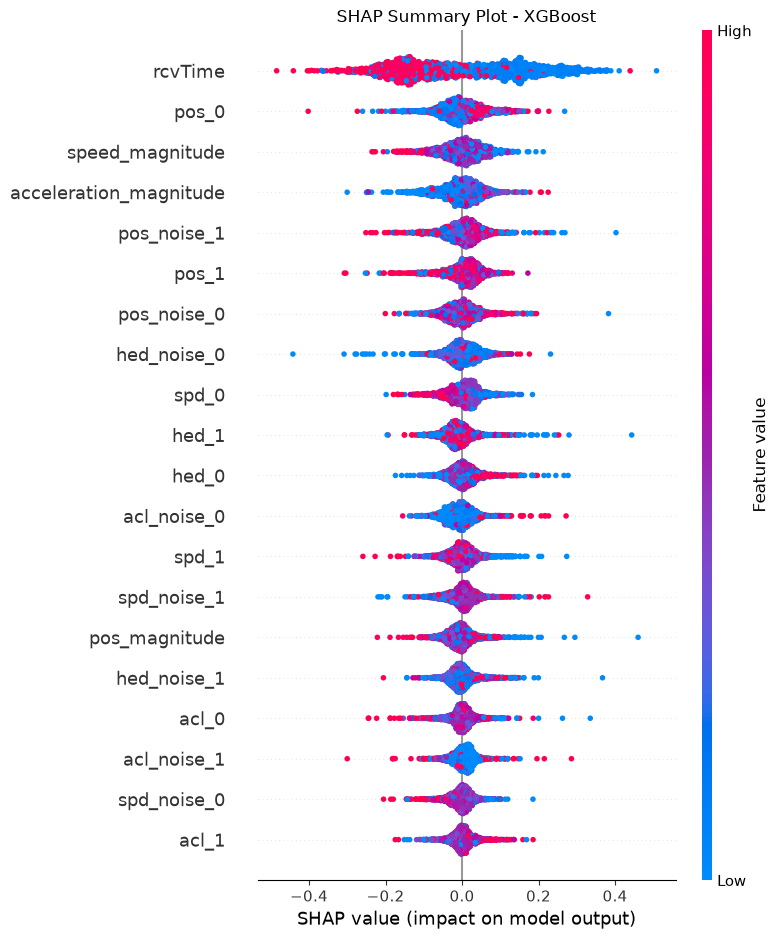

SHAP summary plot saved at: ../outputs/figures/xgb_shap_summary.png


In [30]:
# SHAP Summary Plot

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.title("SHAP Summary Plot - XGBoost")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/xgb_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "SHAP summary plot saved at:",
    "../outputs/figures/xgb_shap_summary.png"
)

## 26.1 SHAP Summary Analysis

The SHAP summary plot provides a global explanation of the XGBoost model by showing both the importance and direction of feature contributions across the selected 2,000 test samples.

The results show that **`rcvTime`** has the largest overall SHAP impact, making it the most influential feature in the current model. This is followed by **`pos_0`**, **`speed_magnitude`**, and **`acceleration_magnitude`**. Several position-, speed-, acceleration-, and heading-related features also contribute to the model predictions.

The distribution of SHAP values shows that the influence of several features varies across individual samples. For example, `rcvTime` exhibits a relatively wide range of SHAP values, indicating that different values of this feature can substantially change the model output. Similarly, `pos_0` and `speed_magnitude` show noticeable variation in their contributions.

The color distribution provides additional information about the relationship between feature values and model output. Features with points distributed on both sides of the zero SHAP-value line can contribute toward either the normal or attack prediction depending on their observed values and the individual sample.

The SHAP analysis therefore provides information that is not available from conventional feature importance alone. While the earlier feature-importance analysis identified globally important features, SHAP additionally shows the **direction and magnitude of their contribution to individual predictions**.

Overall, the SHAP results indicate that the XGBoost model relies primarily on temporal, positional, speed, and acceleration-related information when producing its predictions. These findings provide the basis for the subsequent individual-prediction analysis and the generation of structured explanations for detected misbehavior.


## 27. Mean Absolute SHAP Feature Importance

The mean absolute SHAP value is used to quantify the average magnitude of each feature's contribution to the XGBoost model predictions.

Unlike the SHAP summary plot, which displays the distribution of individual contributions, mean absolute SHAP values provide a numerical ranking of the features according to their overall influence on the model.

A higher mean absolute SHAP value indicates that a feature has a greater average impact on the model output, regardless of whether its contribution is positive or negative.

In [31]:
# Calculate mean absolute SHAP importance

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print(shap_importance)

                   Feature  Mean_Absolute_SHAP
0                  rcvTime            0.141389
1                    pos_0            0.041005
2          speed_magnitude            0.040116
3   acceleration_magnitude            0.038955
4              pos_noise_1            0.035990
5                    pos_1            0.032964
6              pos_noise_0            0.032162
7              hed_noise_0            0.031108
8                    spd_0            0.030526
9                    hed_1            0.028810
10                   hed_0            0.027988
11             acl_noise_0            0.027617
12                   spd_1            0.027293
13             spd_noise_1            0.026811
14           pos_magnitude            0.026769
15             hed_noise_1            0.024076
16                   acl_0            0.022354
17             acl_noise_1            0.021948
18             spd_noise_0            0.021583
19                   acl_1            0.020876
20           

## 27.1 Mean Absolute SHAP Importance Plot

The mean absolute SHAP values are visualized to provide a quantitative ranking of the features according to their average contribution to the XGBoost model.

The ranking confirms that `rcvTime` has the largest average SHAP impact among the evaluated features. Position, speed, acceleration, and noise-related features also show notable contributions.

This visualization complements the SHAP summary plot by presenting the overall magnitude of feature contributions in a simpler ranked format.

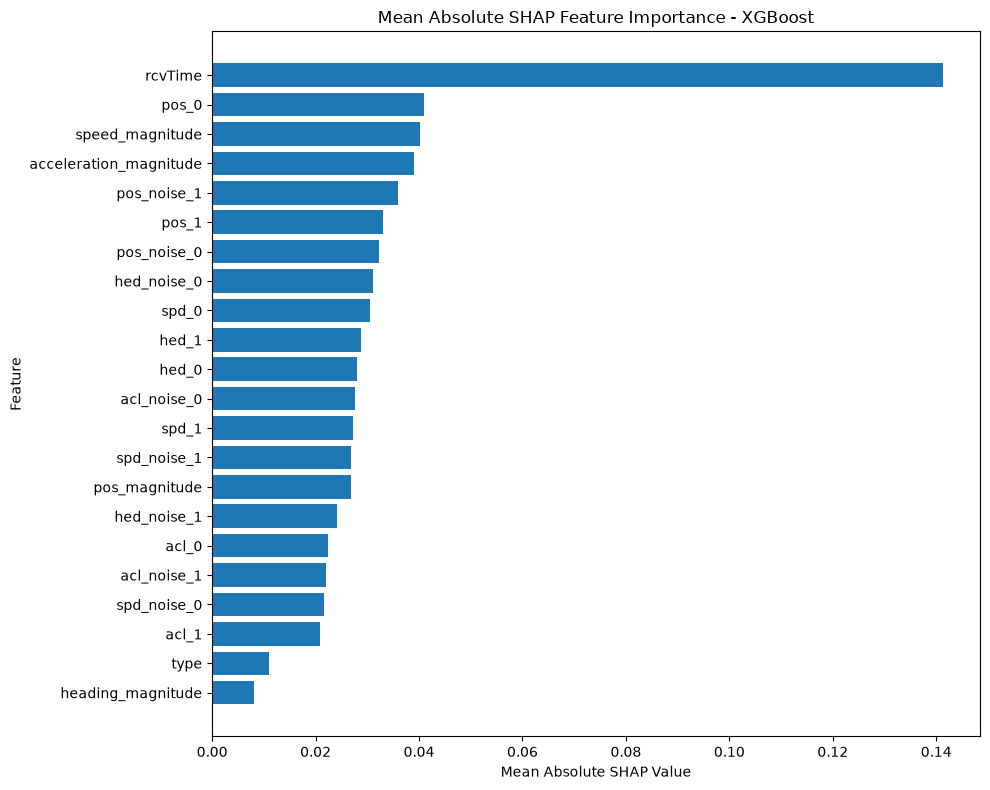

SHAP feature importance figure saved at: ../outputs/figures/xgb_shap_feature_importance.png


In [33]:
# Plot mean absolute SHAP feature importance

plt.figure(figsize=(10, 8))

plt.barh(
    shap_importance["Feature"][::-1],
    shap_importance["Mean_Absolute_SHAP"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Mean Absolute SHAP Feature Importance - XGBoost")

plt.tight_layout()

# Save figure
figure_path = "../outputs/figures/xgb_shap_feature_importance.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP feature importance figure saved at:", figure_path)

## 28. Individual Prediction Explanation

Global SHAP analysis explains the overall behavior of the XGBoost model across multiple samples. However, a misbehavior detection system also requires explanations for individual predictions.

In this section, SHAP values are used to explain the prediction of a single test sample classified by the XGBoost model.

The selected sample is used to identify the features that contributed most strongly toward the model's prediction. Positive SHAP contributions indicate features that push the prediction toward the attack class, while negative contributions push the prediction toward the normal class.

This type of local explanation can be used as the basis for generating an interpretable misbehavior report for an individual vehicle message or observation.

In [38]:
# Find correctly detected attack samples within the SHAP sample

shap_predictions = xgb.predict(X_shap)

y_shap_array = np.asarray(y_shap)

shap_attack_positions = np.where(
    (y_shap_array == 1) & (shap_predictions == 1)
)[0]

print("Correctly detected attacks within SHAP sample:", len(shap_attack_positions))

# Select the first correctly detected attack
sample_position = shap_attack_positions[0]

print("Selected SHAP sample position:", sample_position)
print("Actual class:", y_shap_array[sample_position])
print("Predicted class:", shap_predictions[sample_position])

Correctly detected attacks within SHAP sample: 268
Selected SHAP sample position: 5
Actual class: 1
Predicted class: 1


### 28.1 Local SHAP Values

A local SHAP explanation is generated for the selected correctly detected attack sample.

The SHAP values quantify the contribution of each input feature to the model's prediction for this individual sample. Positive contributions indicate that a feature pushes the prediction toward the attack class, whereas negative contributions push the prediction toward the normal class.

This allows the model's decision for an individual detected misbehavior to be examined rather than relying only on overall feature importance.

In [39]:
# Select the individual sample from the SHAP dataset

X_selected = X_shap.iloc[[sample_position]]

# Create SHAP explainer for the trained XGBoost model
local_explainer = shap.TreeExplainer(xgb)

# Calculate SHAP values for the selected sample
local_shap_values = local_explainer.shap_values(X_selected)

# Convert to NumPy array
local_shap_values = np.asarray(local_shap_values)

print("Selected sample shape:", X_selected.shape)
print("Local SHAP values shape:", local_shap_values.shape)
print("Number of features:", X_selected.shape[1])
print("Number of SHAP values:", local_shap_values.shape[-1])

Selected sample shape: (1, 22)
Local SHAP values shape: (1, 22)
Number of features: 22
Number of SHAP values: 22


### 28.2 Individual Attack Explanation

The individual SHAP explanation is visualized to identify the features that contributed most strongly to the selected attack prediction.

Features with positive SHAP contributions push the model toward the attack class, while features with negative contributions push the model toward the normal class.

The explanation provides a local view of the model's decision-making process and demonstrates how multiple vehicle and message-related features combine to produce an individual attack prediction.

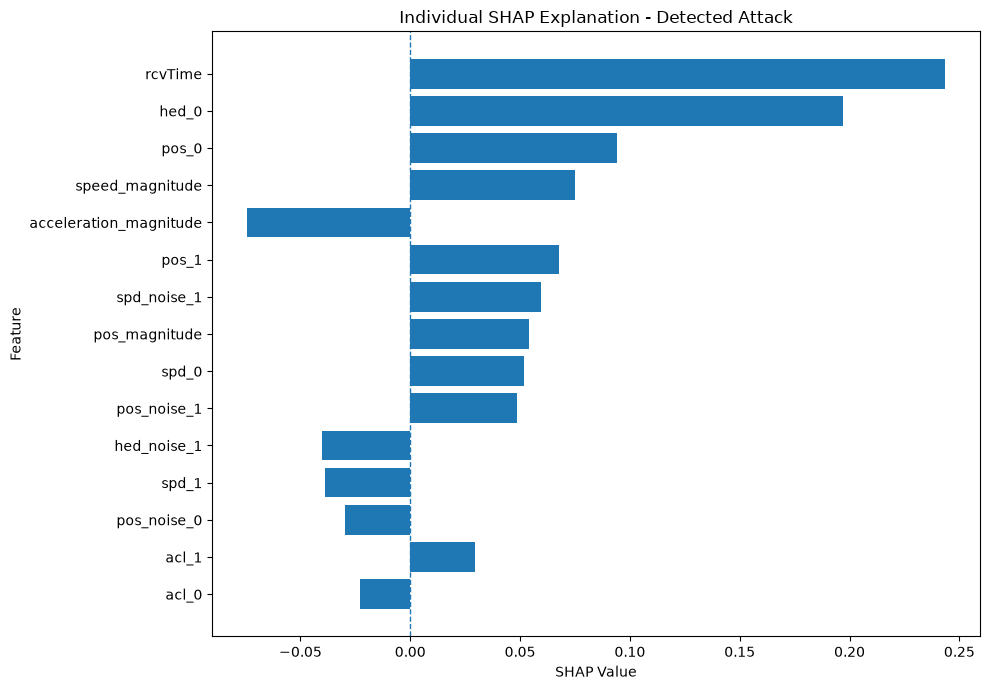

Individual SHAP explanation saved at: ../outputs/figures/xgb_individual_shap_explanation.png

Top contributing features:


,Feature,Feature_Value,SHAP_Value
1,rcvTime,-0.820870,0.243495
14,hed_0,1.660335,0.196799
2,pos_0,-1.019598,0.094013
19,speed_magnitude,-1.257061,0.075147
20,acceleration_magnitude,-0.830756,-0.074297
3,pos_1,-1.426353,0.067677
9,spd_noise_1,0.004528,0.059404
18,pos_magnitude,-1.558106,0.053956
6,spd_0,-0.125895,0.051812
5,pos_noise_1,-0.022711,0.048735


In [41]:
# Create local SHAP explanation plot

plt.figure(figsize=(10, 7))

shap_values_for_plot = local_shap_values[0]

feature_values = X_selected.iloc[0]

local_explanation = pd.DataFrame({
    "Feature": X_selected.columns,
    "SHAP_Value": shap_values_for_plot,
    "Feature_Value": feature_values.values
})

# Sort by absolute SHAP contribution
local_explanation["Abs_SHAP"] = np.abs(
    local_explanation["SHAP_Value"]
)

local_explanation = local_explanation.sort_values(
    by="Abs_SHAP",
    ascending=False
)

# Display top 15 contributing features
top_features = local_explanation.head(15).copy()

plt.barh(
    top_features["Feature"][::-1],
    top_features["SHAP_Value"][::-1]
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title("Individual SHAP Explanation - Detected Attack")

plt.tight_layout()

figure_path = "../outputs/figures/xgb_individual_shap_explanation.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Individual SHAP explanation saved at:",
    figure_path
)

print("\nTop contributing features:")
display(
    top_features[
        ["Feature", "Feature_Value", "SHAP_Value"]
    ]
)